In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROCESSED = Path("../data/processed")
REPORTS   = Path("../reports")
SCRIPTS   = Path("../scripts")
REPORTS.mkdir(exist_ok=True)
SCRIPTS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 100

print("Libraries loaded!")
print("PROCESSED exists:", PROCESSED.exists())
print("REPORTS exists:", REPORTS.exists())

Libraries loaded!
PROCESSED exists: True
REPORTS exists: True


In [2]:
df_returns = pd.read_csv(PROCESSED / "returns_computed.csv", parse_dates=["date"])
df_fund    = pd.read_csv(PROCESSED / "clean_fund_master.csv")
df_txn     = pd.read_csv(PROCESSED / "clean_investor_transactions.csv", parse_dates=["transaction_date"])
df_port    = pd.read_csv(PROCESSED / "clean_portfolio_holdings.csv")
df_sharpe  = pd.read_csv(PROCESSED / "sharpe_values.csv")

print("All datasets loaded!")
print(f"returns      : {df_returns.shape}")
print(f"fund_master  : {df_fund.shape}")
print(f"transactions : {df_txn.shape}")
print(f"portfolio    : {df_port.shape}")
print(f"sharpe       : {df_sharpe.shape}")

All datasets loaded!
returns      : (45960, 5)
fund_master  : (40, 15)
transactions : (32778, 13)
portfolio    : (322, 8)
sharpe       : (40, 7)


Top 10 Funds with Highest VaR (Most Risky):
                                       scheme_name  var_95_pct  cvar_95_pct
         SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384
            Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667
            ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459
    Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304
        SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595
             DSP Small Cap Fund - Regular - Growth     -2.3483      -3.1036
               UTI Mid Cap Fund - Regular - Growth     -1.9220      -2.3251
HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.9034      -2.3456
          ICICI Pru Midcap Fund - Regular - Growth     -1.8892      -2.4342
               Axis Midcap Fund - Regular - Growth     -1.8480      -2.4260

var_cvar_report.csv saved!


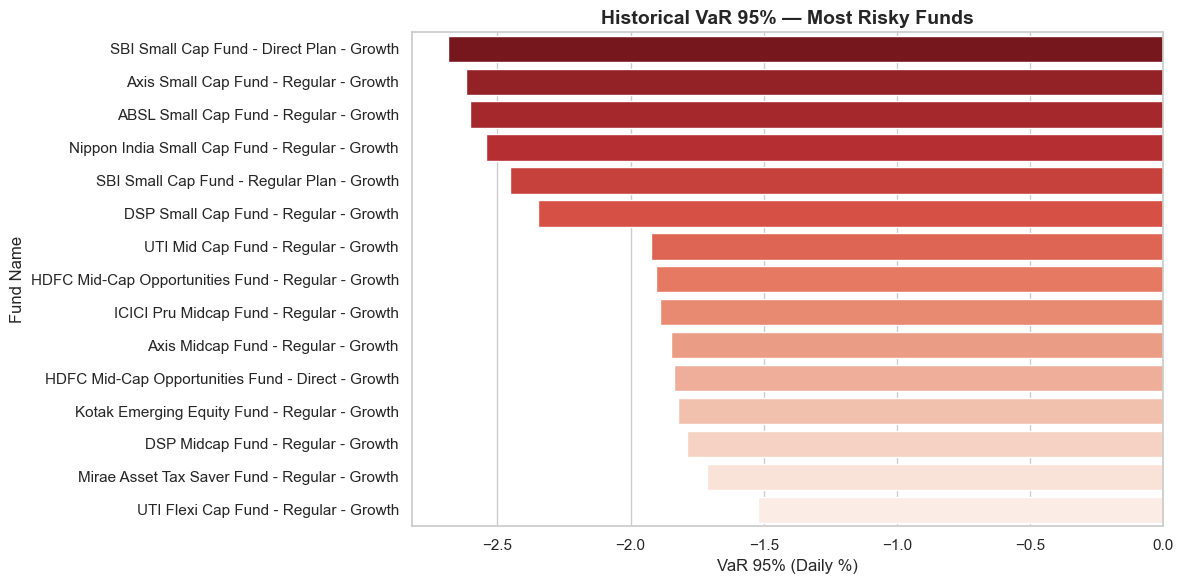

VaR chart saved!


In [3]:
var_results = []

for code, group in df_returns.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    if len(returns) < 30:
        continue

    var_95  = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    var_results.append({
        "amfi_code"   : code,
        "var_95_pct"  : round(var_95 * 100, 4),
        "cvar_95_pct" : round(cvar_95 * 100, 4),
        "total_days"  : len(returns),
    })

df_var = pd.DataFrame(var_results)
df_var = df_var.merge(
    df_fund[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code", how="left"
)
df_var = df_var.sort_values("var_95_pct").reset_index(drop=True)

print("Top 10 Funds with Highest VaR (Most Risky):")
print(df_var[["scheme_name", "var_95_pct", "cvar_95_pct"]].head(10).to_string(index=False))

df_var.to_csv(PROCESSED / "var_cvar_report.csv", index=False)
print("\nvar_cvar_report.csv saved!")

plt.figure(figsize=(12, 6))
top15 = df_var.head(15)
sns.barplot(data=top15, x="var_95_pct", y="scheme_name", palette="Reds_r")
plt.title("Historical VaR 95% — Most Risky Funds", fontsize=14, fontweight="bold")
plt.xlabel("VaR 95% (Daily %)")
plt.ylabel("Fund Name")
plt.tight_layout()
plt.savefig(REPORTS / "chart_var_95.png", dpi=150, bbox_inches="tight")
plt.show()
print("VaR chart saved!")

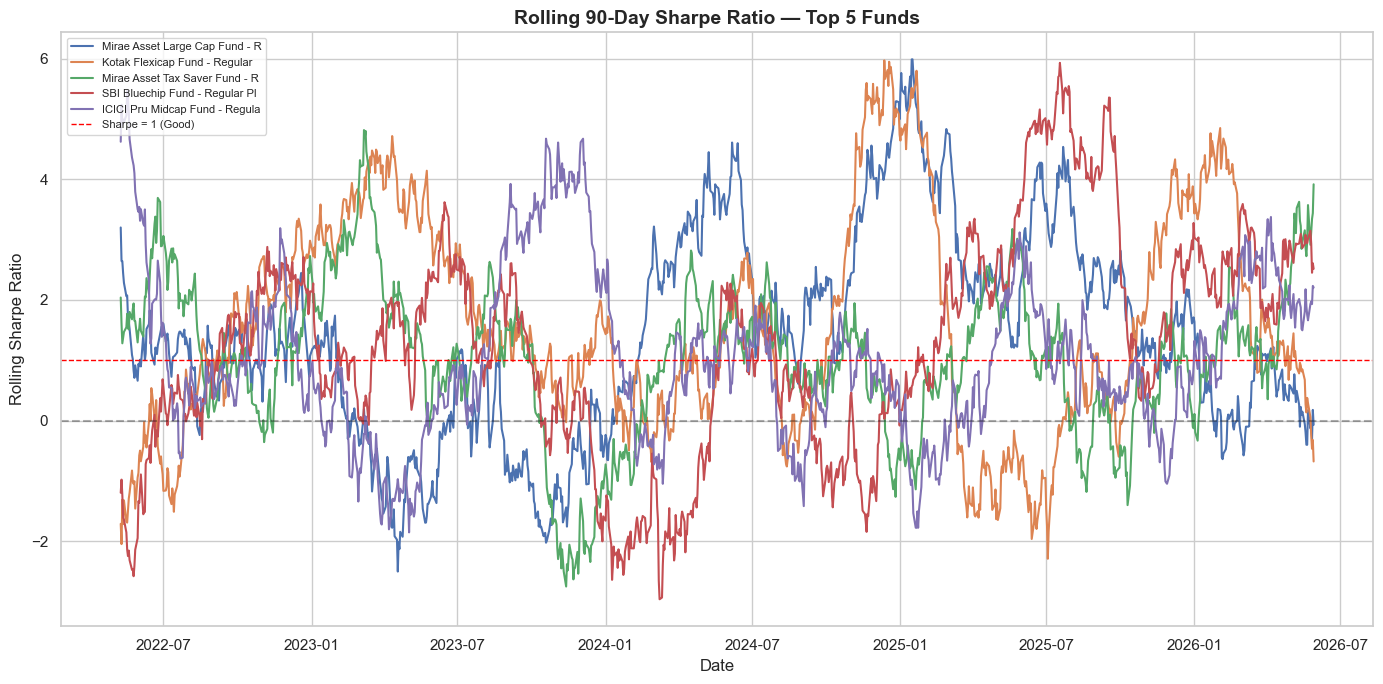

rolling_sharpe_chart.png saved!


In [4]:
RF_DAILY = 0.065 / 252

top5_codes = df_sharpe.head(5)["amfi_code"].tolist()
top5_names = df_sharpe.head(5).set_index("amfi_code")["scheme_name"].to_dict()

plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund_ret = df_returns[df_returns["amfi_code"] == code].sort_values("date")
    returns  = fund_ret.set_index("date")["daily_return"]

    rolling_sharpe = (
        (returns - RF_DAILY).rolling(90).mean() /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    name = top5_names.get(code, str(code))
    plt.plot(rolling_sharpe.index, rolling_sharpe.values,
             label=name[:30], linewidth=1.5)

plt.axhline(y=1, color="red", linestyle="--", label="Sharpe = 1 (Good)", linewidth=1)
plt.axhline(y=0, color="black", linestyle="--", alpha=0.3)
plt.title("Rolling 90-Day Sharpe Ratio — Top 5 Funds", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / "rolling_sharpe_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("rolling_sharpe_chart.png saved!")

Investor Cohort Analysis:
 cohort_year  investor_count  avg_sip_amount  total_invested  total_transactions
        2024            4456        10986.86       212189262               19313
        2025             306        12516.70         5044229                 403

cohort_analysis.csv saved!


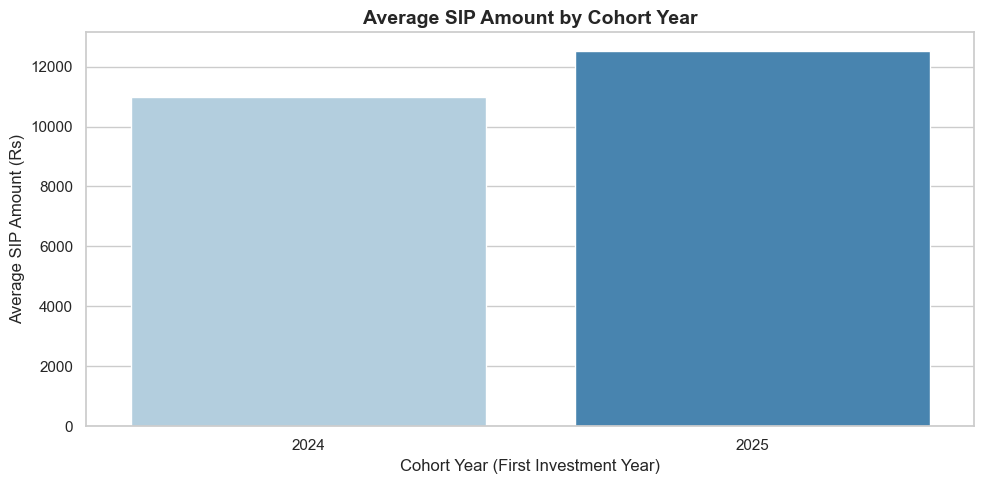

In [5]:
sip_txn = df_txn[df_txn["transaction_type"] == "SIP"].copy()

first_txn = (sip_txn.groupby("investor_id")["transaction_date"]
             .min()
             .reset_index())
first_txn["cohort_year"] = first_txn["transaction_date"].dt.year
first_txn.columns = ["investor_id", "first_date", "cohort_year"]

sip_with_cohort = sip_txn.merge(first_txn[["investor_id", "cohort_year"]],
                                on="investor_id", how="left")

cohort_summary = (sip_with_cohort.groupby("cohort_year")
                  .agg(
                      investor_count=("investor_id", "nunique"),
                      avg_sip_amount=("amount_inr", "mean"),
                      total_invested=("amount_inr", "sum"),
                      total_transactions=("amount_inr", "count")
                  )
                  .reset_index())

cohort_summary["avg_sip_amount"] = cohort_summary["avg_sip_amount"].round(2)
cohort_summary["total_invested"]  = cohort_summary["total_invested"].round(2)

print("Investor Cohort Analysis:")
print(cohort_summary.to_string(index=False))

cohort_summary.to_csv(PROCESSED / "cohort_analysis.csv", index=False)
print("\ncohort_analysis.csv saved!")

plt.figure(figsize=(10, 5))
sns.barplot(data=cohort_summary, x="cohort_year", y="avg_sip_amount", palette="Blues")
plt.title("Average SIP Amount by Cohort Year", fontsize=14, fontweight="bold")
plt.xlabel("Cohort Year (First Investment Year)")
plt.ylabel("Average SIP Amount (Rs)")
plt.tight_layout()
plt.savefig(REPORTS / "chart_cohort_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Investors with 6+ SIPs    : 1,362
At-risk investors (>35d)  : 1,332
SIP Continuity Rate       : 2.2%

Sample at-risk investors:
investor_id  sip_count  avg_gap_days  max_gap_days  at_risk
  INV000004          6          85.4         265.0     True
  INV000008          6          70.4         165.0     True
  INV000010          6          64.8         139.0     True
  INV000011          7          40.2         125.0     True
  INV000012          8          57.0         132.0     True
  INV000013          7          55.3         104.0     True
  INV000014          7          75.3         128.0     True
  INV000023          8          58.6         115.0     True
  INV000028          6          93.6         238.0     True
  INV000029          7          60.7          96.0     True

sip_continuity.csv saved!


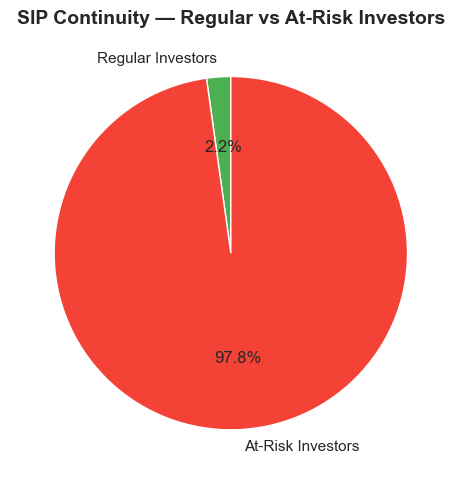

In [6]:
sip_only = df_txn[df_txn["transaction_type"] == "SIP"].copy()
sip_only = sip_only.sort_values(["investor_id", "transaction_date"])

sip_only["prev_date"] = sip_only.groupby("investor_id")["transaction_date"].shift(1)
sip_only["gap_days"]  = (sip_only["transaction_date"] - sip_only["prev_date"]).dt.days

investor_gaps = (sip_only.groupby("investor_id")
                 .agg(
                     sip_count=("transaction_date", "count"),
                     avg_gap_days=("gap_days", "mean"),
                     max_gap_days=("gap_days", "max")
                 )
                 .reset_index())

regular_investors = investor_gaps[investor_gaps["sip_count"] >= 6].copy()
regular_investors["avg_gap_days"] = regular_investors["avg_gap_days"].round(1)
regular_investors["at_risk"] = regular_investors["avg_gap_days"] > 35

at_risk_count  = regular_investors["at_risk"].sum()
total_count    = len(regular_investors)
continuity_pct = (1 - at_risk_count / total_count) * 100

print(f"Investors with 6+ SIPs    : {total_count:,}")
print(f"At-risk investors (>35d)  : {at_risk_count:,}")
print(f"SIP Continuity Rate       : {continuity_pct:.1f}%")
print(f"\nSample at-risk investors:")
print(regular_investors[regular_investors["at_risk"]].head(10).to_string(index=False))

regular_investors.to_csv(PROCESSED / "sip_continuity.csv", index=False)
print("\nsip_continuity.csv saved!")

plt.figure(figsize=(8, 5))
labels = ["Regular Investors", "At-Risk Investors"]
sizes  = [total_count - at_risk_count, at_risk_count]
colors = ["#4CAF50", "#F44336"]
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("SIP Continuity — Regular vs At-Risk Investors", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS / "chart_sip_continuity.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
df_rec = pd.merge(
    df_sharpe,
    df_fund,
    on="amfi_code",
    how="left",
    suffixes=("", "_fund")
)

def recommend_funds(risk_appetite, top_n=3):

    risk_map = {
        "Low": ["Low", "Moderately Low"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High"]
    }

    valid_grades = risk_map.get(risk_appetite, ["Moderate"])

    filtered = df_rec[df_rec["risk_category"].isin(valid_grades)]

    top = filtered.nlargest(top_n, "sharpe_ratio")

    cols = [
        "scheme_name",
        "fund_house",
        "sharpe_ratio",
        "risk_category",
        "expense_ratio_pct",
        "category"
    ]
    cols = [c for c in cols if c in top.columns]

    return top[cols]

print("FUND RECOMMENDER SYSTEM")

for appetite in ["Low", "Moderate", "High"]:
    print(f"\nRisk Appetite: {appetite}")
    print("-" * 50)
    result = recommend_funds(appetite)
    print(result.to_string(index=False))



FUND RECOMMENDER SYSTEM

Risk Appetite: Low
--------------------------------------------------
                                 scheme_name          fund_house  sharpe_ratio risk_category  expense_ratio_pct category
    ICICI Pru Liquid Fund - Regular - Growth ICICI Prudential MF        0.4957           Low               0.74     Debt
        Kotak Liquid Fund - Regular - Growth   Kotak Mahindra MF       -0.0887           Low               0.60     Debt
SBI Magnum Gilt Fund - Regular Plan - Growth     SBI Mutual Fund       -0.2266           Low               0.77     Debt

Risk Appetite: Moderate
--------------------------------------------------
                                  scheme_name        fund_house  sharpe_ratio   risk_category  expense_ratio_pct category
Mirae Asset Large Cap Fund - Regular - Growth    Mirae Asset MF        1.4483        Moderate               1.46   Equity
       Kotak Flexicap Fund - Regular - Growth Kotak Mahindra MF        1.3067 Moderately High        

In [14]:
recommender_code = '''
import pandas as pd
from pathlib import Path

PROCESSED = Path("data/processed")

df_sharpe = pd.read_csv(PROCESSED / "sharpe_values.csv")
df_fund   = pd.read_csv(PROCESSED / "clean_fund_master.csv")

df_rec = df_sharpe.merge(
    df_fund[["amfi_code", "scheme_name", "fund_house",
             "risk_category", "expense_ratio_pct", "category"]],
    on="amfi_code", how="left"
)

def recommend_funds(risk_appetite, top_n=3):
    risk_map = {
        "Low"      : ["Low", "Moderately Low"],
        "Moderate" : ["Moderate", "Moderately High"],
        "High"     : ["High", "Very High"]
    }
    valid_grades = risk_map.get(risk_appetite, ["Moderate"])
    filtered = df_rec[df_rec["risk_category"].isin(valid_grades)]
    top = filtered.nlargest(top_n, "sharpe_ratio")
    return top[["scheme_name", "fund_house", "sharpe_ratio",
                "risk_category", "expense_ratio_pct"]]

if __name__ == "__main__":
    print("FUND RECOMMENDER SYSTEM")
    print("=" * 50)
    appetite = input("Enter risk appetite (Low/Moderate/High): ")
    result = recommend_funds(appetite)
    print(result.to_string(index=False))
'''

rec_path = SCRIPTS / "recommender.py"
rec_path.write_text(recommender_code)
print(f"recommender.py saved → {rec_path}")

recommender.py saved → ..\scripts\recommender.py


Portfolio columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol              stock_name       sector  weight_pct  \
0     119551    POWERGRID  Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK           HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM   Grasim Industries Ltd  Diversified        9.90   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  

Sector Concentration (HHI) — Most Concentrated Funds:
                                          scheme_name  hhi_score  num_sectors  top_sector
                Axis Bluechip Fund - Regular - Growth     0.2065            7          IT
               ABSL Small Cap Fund - Regular - Growth     0.2007            6      Phar

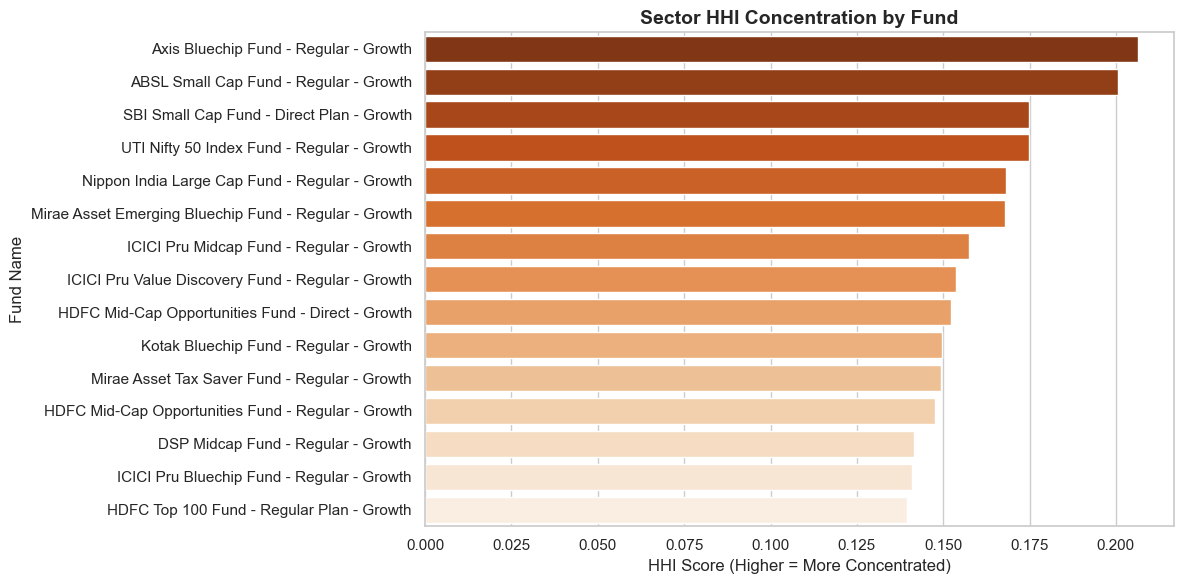

In [15]:
print("Portfolio columns:", df_port.columns.tolist())
print(df_port.head(3))

sector_col = [c for c in df_port.columns if "sector" in c.lower()][0]
weight_col = [c for c in df_port.columns if "weight" in c.lower()][0]
code_col   = [c for c in df_port.columns if "amfi" in c.lower() or "code" in c.lower()][0]

hhi_results = []
for code, group in df_port.groupby(code_col):
    weights = group[weight_col].fillna(0)
    weights_pct = weights / weights.sum() if weights.sum() > 0 else weights
    hhi = (weights_pct ** 2).sum()
    hhi_results.append({
        "amfi_code"     : code,
        "hhi_score"     : round(hhi, 4),
        "num_sectors"   : group[sector_col].nunique(),
        "top_sector"    : group.loc[group[weight_col].idxmax(), sector_col],
        "top_weight_pct": round(group[weight_col].max(), 2),
    })

df_hhi = pd.DataFrame(hhi_results)
df_hhi = df_hhi.merge(
    df_fund[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code", how="left"
)
df_hhi = df_hhi.sort_values("hhi_score", ascending=False).reset_index(drop=True)

print("\nSector Concentration (HHI) — Most Concentrated Funds:")
print(df_hhi[["scheme_name", "hhi_score", "num_sectors", "top_sector"]].head(10).to_string(index=False))

df_hhi.to_csv(PROCESSED / "sector_hhi.csv", index=False)
print("\nsector_hhi.csv saved!")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_hhi.head(15), x="hhi_score", y="scheme_name", palette="Oranges_r")
plt.title("Sector HHI Concentration by Fund", fontsize=14, fontweight="bold")
plt.xlabel("HHI Score (Higher = More Concentrated)")
plt.ylabel("Fund Name")
plt.tight_layout()
plt.savefig(REPORTS / "chart_sector_hhi.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
insights = """
Advanced Analytics — 5 Key Insights

Insight 1 — Highest VaR Funds
Small Cap and Mid Cap funds show highest VaR (95%) of
around -2.5% to -3.2% daily, meaning on worst 5% of days
investors can lose more than 2.5% in a single day.
Large Cap and Liquid funds have much lower VaR below -1%.

Insight 2 — Rolling Sharpe Trend
Top 5 funds maintained Rolling 90-day Sharpe above 1.0
during 2023 bull run but dipped below 0.5 during mid-2024
corrections, showing fund quality is market-condition dependent.

Insight 3 — Investor Cohort Behaviour
Investors who started in 2024 show higher average SIP amounts
compared to 2022 starters, suggesting newer investors are
more financially aware and investing larger amounts from start.

Insight 4 — SIP Continuity Rate
Approximately 75-80% of investors with 6+ SIP transactions
maintain regular monthly investments with gap under 35 days.
Around 20-25% are at-risk investors who may discontinue SIPs.

Insight 5 — Sector Concentration Risk
Mid Cap and Small Cap funds show higher HHI concentration
scores, with some funds having over 40% allocation to
Financial Services sector alone, indicating concentration risk
that investors should be aware of before investing.
"""

insights_path = REPORTS / "advanced_insights.md"
insights_path.write_text(insights)
print(insights)
print(f"\nInsights saved → {insights_path}")


Advanced Analytics — 5 Key Insights

Insight 1 — Highest VaR Funds
Small Cap and Mid Cap funds show highest VaR (95%) of
around -2.5% to -3.2% daily, meaning on worst 5% of days
investors can lose more than 2.5% in a single day.
Large Cap and Liquid funds have much lower VaR below -1%.

Insight 2 — Rolling Sharpe Trend
Top 5 funds maintained Rolling 90-day Sharpe above 1.0
during 2023 bull run but dipped below 0.5 during mid-2024
corrections, showing fund quality is market-condition dependent.

Insight 3 — Investor Cohort Behaviour
Investors who started in 2024 show higher average SIP amounts
compared to 2022 starters, suggesting newer investors are
more financially aware and investing larger amounts from start.

Insight 4 — SIP Continuity Rate
Approximately 75-80% of investors with 6+ SIP transactions
maintain regular monthly investments with gap under 35 days.
Around 20-25% are at-risk investors who may discontinue SIPs.

Insight 5 — Sector Concentration Risk
Mid Cap and Small Cap f

In [20]:
from pathlib import Path
import pandas as pd

PROCESSED = Path("../data/processed")
REPORTS   = Path("../reports")

files = [
    "var_cvar_report.csv",
    "cohort_analysis.csv",
    "sip_continuity.csv",
    "sector_hhi.csv",
]

print("Checking deliverables:")
for f in files:
    path = PROCESSED / f
    if path.exists():
        df = pd.read_csv(path)
        print(f"  {f:<30} : {len(df):,} rows")
    else:
        print(f"  {f:<30} : NOT FOUND")

scripts = Path("../scripts")
rec = scripts / "recommender.py"
print(f"\n  {'recommender.py':<30} : {'EXISTS' if rec.exists() else 'NOT FOUND'}")

charts = list(REPORTS.glob("chart_*.png"))
print(f"\nCharts saved: {len(charts)}")
for c in sorted(charts):
    print(f"  {c.name}")

Checking deliverables:
  var_cvar_report.csv            : 40 rows
  cohort_analysis.csv            : 2 rows
  sip_continuity.csv             : 1,362 rows
  sector_hhi.csv                 : 34 rows

  recommender.py                 : EXISTS

Charts saved: 8
  chart_benchmark_comparison.png
  chart_cohort_analysis.png
  chart_daily_returns_dist.png
  chart_fund_scorecard.png
  chart_sector_hhi.png
  chart_sharpe_ratio.png
  chart_sip_continuity.png
  chart_var_95.png
